In [371]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import floor, sqrt
import torch
import torch.nn as nn

In [372]:
def torch_sigmoid(x):
    return torch.sigmoid(x)

def torch_relu(x):
    return torch.relu(x)

def torch_leaky_relu(x, alpha=0.01):
    return torch.nn.functional.leaky_relu(x, negative_slope=alpha)

def torch_softmax(x):
    return torch.softmax(x, dim=1)

In [373]:
class LinCell(nn.Module):
    def __init__(self, inp_dim, out_dim):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(inp_dim, out_dim) * np.sqrt(2.0 / inp_dim))
        self.bias = nn.Parameter(torch.zeros(1, out_dim))
        self.input_dim = inp_dim
        self.output_dim = out_dim

    def forward(self, x):
        return x @ self.weights + self.bias
    
class ActivationCell(nn.Module):
    def __init__(self, activation_func):
        super().__init__()
        self.activation = activation_func

    def forward(self, x):
        return self.activation(x)
    
class NeuralNet(nn.Module):
    def __init__(self, layer_types, inp_dims, out_dims):
        super().__init__()
        self.layer_types = layer_types
        self.inp_dims = inp_dims
        self.out_dims = out_dims
        self.layers = nn.ModuleList()
        idx = 0
        for ltype in layer_types:
            ltype_lower = ltype.lower()
            if ltype_lower == "linear":
                self.layers.append(LinCell(inp_dims[idx], out_dims[idx]))
                idx += 1
            elif ltype_lower == "relu":
                self.layers.append(ActivationCell(torch_relu))
            elif ltype_lower == "sigmoid":
                self.layers.append(ActivationCell(torch_sigmoid))
            elif ltype_lower == "tanh":
                self.layers.append(ActivationCell(torch.tanh))
            elif ltype_lower == "leakyrelu":
                self.layers.append(ActivationCell(lambda x: torch_leaky_relu(x)))
            elif ltype_lower == "softmax":
                self.layers.append(ActivationCell(lambda x: torch_softmax(x)))
            else:
                raise ValueError(f"Unsupported layer type: {ltype}")

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def save(self, filename="neural.pth"):
        checkpoint = {
            'layer_types': self.layer_types,
            'inp_dims': self.inp_dims,
            'out_dims': self.out_dims,
            'state_dict': self.state_dict()
        }
        torch.save(checkpoint, filename)

    def load(self, filename="neural.pth"):
        checkpoint = torch.load(filename, map_location='cpu')
        if (checkpoint['layer_types'] != self.layer_types or
            checkpoint['inp_dims'] != self.inp_dims or
            checkpoint['out_dims'] != self.out_dims):
            print("警告：加载的模型结构与当前网络不完全一致，可能出错。")
        self.load_state_dict(checkpoint['state_dict'])

    def meanSquareError(self, X, Y):
        if not isinstance(X, torch.Tensor):
            X = torch.tensor(X, dtype=torch.float32)
        if not isinstance(Y, torch.Tensor):
            Y = torch.tensor(Y, dtype=torch.float32)
        was_training = self.training
        self.training = False
        with torch.no_grad():
            pred = self.forward(X)
            loss = torch.mean((pred - Y) ** 2)
        self.training = was_training
        return loss.item()

    def train(self, X, Y, learning_rate):
        if not hasattr(self, 'optimizer'):
            #self.optimizer = torch.optim.Adam(self.parameters(), lr=learning_rate)
            self.optimizer = torch.optim.SGD(self.parameters(),lr=learning_rate,momentum=0.3,weight_decay=1e-2)
        else:
            for param_group in self.optimizer.param_groups:
                param_group['lr'] = learning_rate

        if not isinstance(X, torch.Tensor):
            X = torch.tensor(X, dtype=torch.float32)
        if not isinstance(Y, torch.Tensor):
            Y = torch.tensor(Y, dtype=torch.float32)

        self.training = True
        self.optimizer.zero_grad()
        pred = self.forward(X)
        loss = torch.mean((pred - Y) ** 2)
        loss.backward()
        self.optimizer.step()
        return loss.item()

提取数据

In [374]:
train_df = pd.read_csv("train.csv")
valid_df = pd.read_csv("validation.csv")
test_df = pd.read_csv("test.csv")
#feature_cols = ["np","nn","delta","I", "betaMinusQ", "betaMinusQUncertainty", "halflife_log_sec_uncertainty"]
#feature_cols = ["np", "nn", "delta", "I","betaMinusQ", "betaMinusQUncertainty", "halflife_log_sec_uncertainty","delta_J", "delta_parity"]
feature_cols = ["np", "nn", "delta", "I","betaMinusQ", "betaMinusQUncertainty", "halflife_log_sec_uncertainty","J_i", "parity_i", "flag_i","J_f", "parity_f", "flag_f","delta_J", "delta_parity"]
#feature_cols = ["np", "na", "betaMinusQ", "betaMinusQUncertainty"]
target_cols = ["halflife_log_sec"]

trainX = train_df[feature_cols].values
trainY = train_df[target_cols].values

validX = valid_df[feature_cols].values
validY = valid_df[target_cols].values

testX = test_df[feature_cols].values
testY = test_df[target_cols].values

输入归一化

In [375]:
NotNor_tr = trainX
NotNor_va = validX
NotNor_te = testX
#核子数类：np(第0列), na(第1列) 除以 118
trainX = trainX.copy().astype(float)
validX = validX.copy().astype(float)
testX = testX.copy().astype(float)

trainX[:, 0] /= 118.0   # np
trainX[:, 1] /= 118.0   # na
validX[:, 0] /= 118.0
validX[:, 1] /= 118.0
testX[:, 0] /= 118.0
testX[:, 1] /= 118.0

#其余特征（从第2列开始）除以三个集合的最大值
#拼接三个集合，计算每列最大值
other_cols_start = 2   # 假设第0列np，第1列na，其余从第2列起
all_other = np.vstack([trainX[:, other_cols_start:],
                       validX[:, other_cols_start:],
                       testX[:, other_cols_start:]])
max_vals = np.max(all_other, axis=0)

#对各集合的其余特征除以对应最大值
trainX[:, other_cols_start:] /= max_vals
validX[:, other_cols_start:] /= max_vals
testX[:, other_cols_start:] /= max_vals

trainX = torch.tensor(trainX, dtype=torch.float32)
trainY = torch.tensor(trainY, dtype=torch.float32)
validX = torch.tensor(validX, dtype=torch.float32)
validY = torch.tensor(validY, dtype=torch.float32)
testX  = torch.tensor(testX,  dtype=torch.float32)
testY  = torch.tensor(testY,  dtype=torch.float32)

建立神经网络

In [376]:
NNeurons = 32
NLayers = 6
dim_Input =len(feature_cols)
dim_Target = len(target_cols)
inp = [dim_Input]
opt = [NNeurons]
types = ["linear","relu"]
for i in range(NLayers-2):
    types.append("linear")
    types.append("leakyrelu")
    inp.append(NNeurons)
    opt.append(NNeurons)
types.append("linear")
inp.append(NNeurons)
opt.append(dim_Target)
neural=NeuralNet(types,inp,opt)
neural.load()

警告：加载的模型结构与当前网络不完全一致，可能出错。


训练

Среднеквадратичная ошибка для обучающей выборки: 0.575184166431427
Среднеквадратичная ошибка для тестовой выборки: 0.395198792219162
Среднеквадратичная ошибка для валидационной выборки: 0.4696708023548126


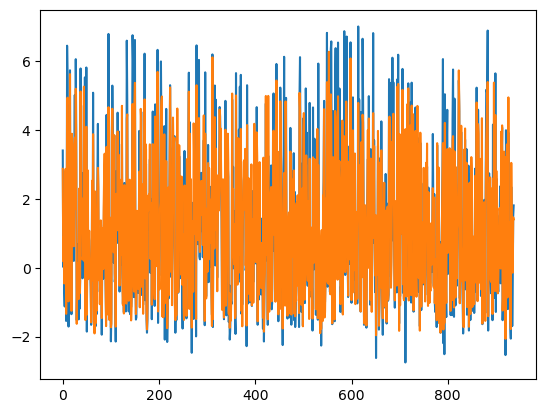

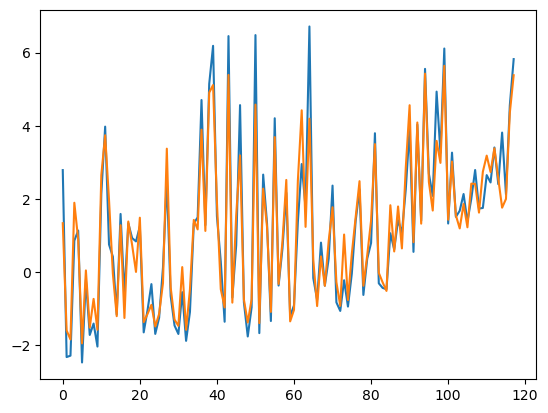

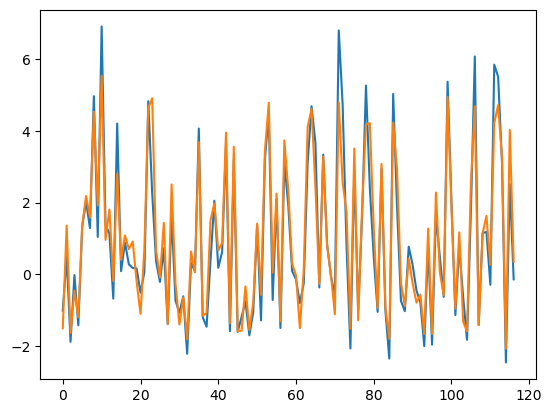

In [377]:
print(f"Среднеквадратичная ошибка для обучающей выборки: {neural.meanSquareError(trainX, trainY)}")
print(f"Среднеквадратичная ошибка для тестовой выборки: {neural.meanSquareError(testX, testY)}")
print(f"Среднеквадратичная ошибка для валидационной выборки: {neural.meanSquareError(validX, validY)}")

plt.plot(trainY)
plt.plot(neural.forward(trainX).detach().numpy())
plt.show()
plt.plot(testY)
plt.plot(neural.forward(testX).detach().numpy())
plt.show()
plt.plot(validY)
plt.plot(neural.forward(validX).detach().numpy())
plt.show()

In [378]:
elements = [
    'H', 'He', 'Li', 'Be', 'B', 'C', 'N', 'O', 'F', 'Ne',
    'Na', 'Mg', 'Al', 'Si', 'P', 'S', 'Cl', 'Ar', 'K', 'Ca',
    'Sc', 'Ti', 'V', 'Cr', 'Mn', 'Fe', 'Co', 'Ni', 'Cu', 'Zn',
    'Ga', 'Ge', 'As', 'Se', 'Br', 'Kr', 'Rb', 'Sr', 'Y', 'Zr',
    'Nb', 'Mo', 'Tc', 'Ru', 'Rh', 'Pd', 'Ag', 'Cd', 'In', 'Sn',
    'Sb', 'Te', 'I', 'Xe', 'Cs', 'Ba', 'La', 'Ce', 'Pr', 'Nd',
    'Pm', 'Sm', 'Eu', 'Gd', 'Tb', 'Dy', 'Ho', 'Er', 'Tm', 'Yb',
    'Lu', 'Hf', 'Ta', 'W', 'Re', 'Os', 'Ir', 'Pt', 'Au', 'Hg',
    'Tl', 'Pb', 'Bi', 'Po', 'At', 'Rn', 'Fr', 'Ra', 'Ac', 'Th',
    'Pa', 'U', 'Np', 'Pu', 'Am', 'Cm', 'Bk', 'Cf', 'Es', 'Fm',
    'Md', 'No', 'Lr', 'Rf', 'Db', 'Sg', 'Bh', 'Hs', 'Mt', 'Ds',
    'Rg', 'Cn', 'Nh', 'Fl', 'Mc', 'Lv', 'Ts', 'Og'
]

绘制带误差棒的散点图

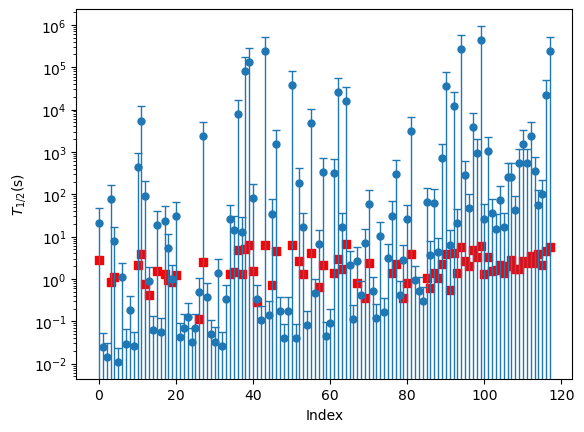

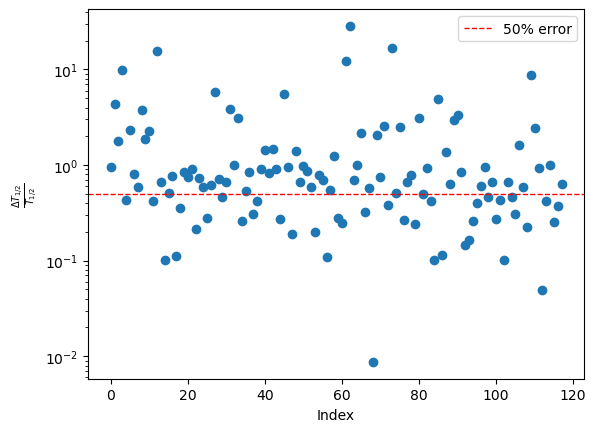

['Og1', 'Be14', 'B17', 'N16', 'O20', 'F29', 'Ne25', 'Ne28', 'Al35', 'Al38', 'Al28', 'Si31', 'P36', 'S41', 'S45', 'Cl41', 'Ar49', 'Ar45', 'Ar46', 'K48', 'K47', 'Ca55', 'Ca54', 'Ca53', 'Sc57', 'Ti58', 'Ti55', 'Ti51', 'V56', 'Mn68', 'Mn70', 'Mn63', 'Fe73', 'Co71', 'Ni67', 'Ga76', 'Ga72', 'Ge79', 'As77', 'As74', 'As81', 'Br90', 'Kr98', 'Rb84', 'Y104', 'Y96', 'Y93', 'Zr107', 'Nb114', 'Nb109', 'Nb95', 'Tc120', 'Tc105', 'Tc107', 'Ru120', 'Ru105', 'Rh117', 'Pd117', 'Pd114', 'Cd133', 'In134', 'In121', 'In112', 'Sn131', 'Sb124', 'Sb134', 'Sb140', 'I138', 'I141', 'I139', 'Xe137', 'Xe146', 'Xe148', 'Cs145', 'Cs149', 'Ba147', 'La145', 'Ce145', 'Ce156', 'Pr154', 'Pr150', 'Nd149', 'Nd159', 'Pm163', 'Sm167', 'Sm159', 'Eu164', 'Eu161', 'Eu162', 'Tb164', 'Dy165', 'Dy172', 'Ho167', 'Ho172', 'Yb175', 'Yb179', 'Lu182', 'W187', 'W190', 'Os191', 'Ir201', 'Pt199', 'Au205', 'Au206', 'Hg208', 'Tl213', 'Pb216', 'Pb213', 'At222', 'At219', 'Rn226', 'Rn225', 'Ra227', 'Ra232', 'Pa239', 'Np242', 'Am244', 'Es257']


In [379]:
T_HL_test = np.power(10,neural.forward(testX).detach().numpy()).squeeze()
T_HL_calc = np.power(10,testY).squeeze()
T_HL_test_error = sqrt(neural.meanSquareError(testX,testY))*0.8*np.log(10)*T_HL_test
T_HL_test_error=T_HL_test_error.squeeze()
x = np.arange(len(T_HL_test))
plt.errorbar(x, T_HL_test, yerr=T_HL_test_error, fmt='o',capsize=3,elinewidth=1,markersize=5)
plt.scatter(x,testY,color='red', marker='s')
plt.yscale('log')
plt.xlabel('Index')
plt.ylabel('$T_{1/2}$(s)')
plt.show()
plt.scatter(x, abs(T_HL_calc - T_HL_test) / np.maximum(T_HL_calc, 0))
plt.yscale('log')
plt.xlabel('Index')
plt.ylabel('$\\frac{ΔT_{1/2}}{T_{1/2}}$')
plt.axhline(y=0.5, color='red', linestyle='--', linewidth=1, label='50% error')
plt.legend()
plt.show()
Isotropes = []
for i in range(len(T_HL_test)):
    Isotropes.append(elements[int(NotNor_te[i][0])-1]+str(int(NotNor_te[i][1]+NotNor_te[i][0])))
print(Isotropes)
pd.DataFrame({
    'Isotope': Isotropes,
    'Np': [int(NotNor_te[i][0]) for i in range(len(Isotropes))],
    'Nn': [int(NotNor_te[i][1]) for i in range(len(Isotropes))],
    'Actual_HL(s)': T_HL_calc,
    'Predicted_HL(s)': T_HL_test,
    'Error': T_HL_test_error
}).to_csv('calc_test.csv', index=False)